In [3]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [4]:
new_users = pd.read_csv('users.csv')
purchases = pd.read_csv('purchases.csv')

Данные о новых пользователях включают в себя:
user_id - уникальный идентификатор пользователя;
dt - дату регистрации пользователя;
ad_network - название рекламной сети, с помощью которой был привлечен пользователь.

Данные о покупках включают в себя:
user_id - уникальный идентификатор пользователя;
event_dt - дату совершения покупки;
revenue - сумму покупки (в долларах);
ad_network - название рекламной сети, с помощью которой был привлечен пользователь.

,count,mean,std,min,25%,50%,75%,max
revenue,3399.0,29.519176,16.774518,4.99,19.96,24.96,34.96,149.91


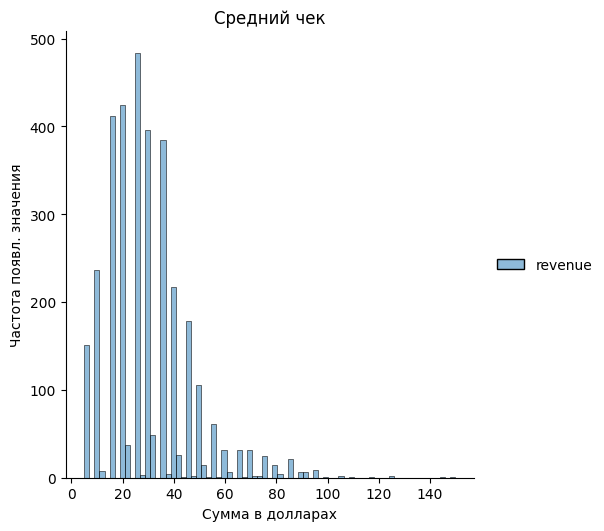

In [13]:
report = purchases.groupby('user_id').agg({'revenue': 'sum'})
display(report.describe().T)
sns.displot(report) # количество бинов определяется алгоритмом Freedman-Diaconis, если не указать
plt.title('Индивидуальный чек'), plt.xlabel('Сумма в долларах'), plt.ylabel('Частота появл. значения');

In [15]:
buyers = purchases['user_id'].nunique() # считаем количество уникальных покупателей
total = new_users['user_id'].nunique()
print('Вероятность стать покупателем: {:.2%} ({} покупателей из {} уникальных пользователей)'.format(buyers / total, buyers, total))

Вероятность стать покупателем: 2.04% (3399 покупателей из 166447 уникальных пользователей)


,count,mean,std,min,25%,50%,75%,max
revenue,3399.0,29.519176,16.774518,4.99,19.96,24.96,34.96,149.91


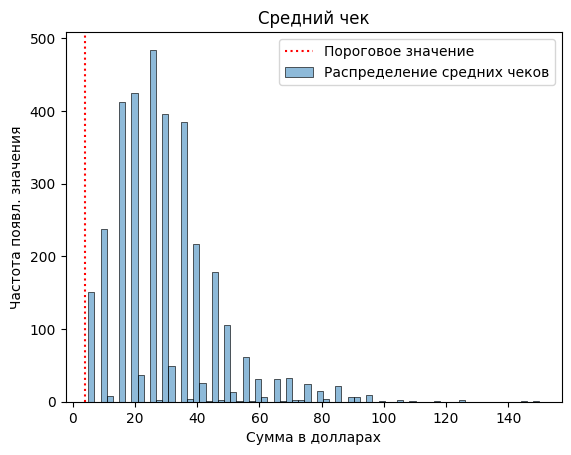

In [22]:
report = purchases.groupby('user_id').agg({'revenue': 'sum'})
display(report.describe().T)
ax = sns.histplot(report, label = 'Распределение индивидуальных чеков')
ax.axvline(x = 4, color = 'red', linestyle = ':', label = 'Пороговое значение')
plt.legend(), plt.title('Индивидуальный чек'), plt.xlabel('Сумма в долларах'), plt.ylabel('Частота появл. значения');

In [23]:
report = purchases.groupby('user_id').agg({'ad_network': 'first', 'revenue': 'sum'})
report.head(5)

,ad_network,revenue
user_id,,
0026a8f0dc63d2f9,FB,44.91
0031622f6c255f06,Instagroom,44.91
004d717fa0b99cdb,Instagroom,14.97
0051725df72fadd4,FB,24.95
0075709c27879d34,FB,9.98


Среднее для FB: 28.64
Среднее для Instagroom: 31.32


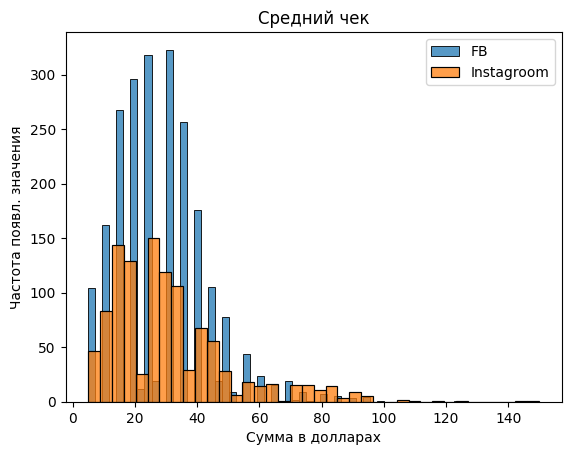

In [29]:
for adn in report['ad_network'].unique():
    current = report.query('ad_network == @adn')['revenue']
    sns.histplot(current, label = adn)
    print('Среднее для {}: {:.2f}'.format(adn, current.mean()))
    plt.legend(), plt.title('Индивидуальный чек'), plt.xlabel('Сумма в долларах'), plt.ylabel('Частота появл. значения');

Посмотрим, как t-тест работает на примере. Протестируем, равно ли среднее значение
пользовательского чека пороговому значению.

Средний чек: 29.52
p-value: 0.00000
Отвергаем нулевую гипотезу: среднее не равно заданному порогу.


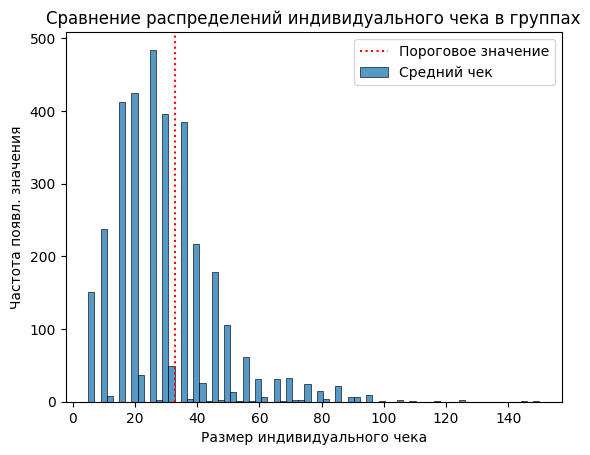

In [8]:
import scipy.stats as stats
# задаем порог
value = 33
# готовим данные
report = purchases.groupby('user_id').agg({'revenue': 'sum'})['revenue']
ax = sns.histplot(report, label = 'Средний чек')
ax.axvline(x = value, color = 'red', linestyle = ':', label = 'Пороговое значение')
print('Средний чек: {:.2f}'.format(report.mean()))
plt.legend(), plt.xlabel('Размер индивидуального чека'), plt.ylabel('Частота появл. значения'),
plt.title('Сравнение распределений индивидуального чека в группах');
# задаем уровень значимости
alpha = 0.05
#проводим тест
p_value = stats.ttest_1samp(report, popmean = value)[1]
print('p-value: {:.5f}'.format(p_value))
# анализируем результат
if p_value < alpha:
    print('Отвергаем нулевую гипотезу: среднее не равно заданному порогу.')
else:
    print('Не отвергаем нулевую гипотезу: среднее равно заданному порогу.')

Посмотрим, как двухвыборочный t-тест работает на примере. Протестируем различия среднего чека
для пользователей, привлеченных из рекламных сетей FB и Instagroom.

Средний чек для FB: 28.64
Средний чек для Instagroom: 31.32
p-value: 0.00007
Отвергаем нулевую гипотезу: средние в двух группах не равны.


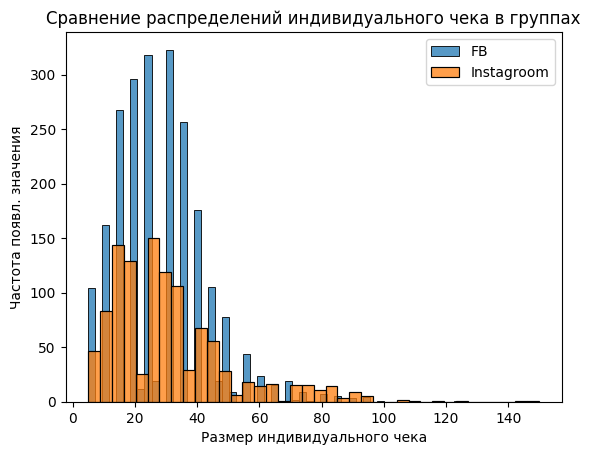

In [10]:
import scipy.stats as stats
# готовим данные
report = purchases.groupby('user_id').agg({'ad_network': 'first', 'revenue': 'sum'})
for adn in report['ad_network'].unique():
    current = report.query('ad_network == @adn')['revenue']
    sns.histplot(current, label = adn)
    print('Средний чек для {}: {:.2f}'.format(adn, current.mean()))
    
plt.legend(), plt.xlabel('Размер индивидуального чека'), plt.ylabel('Частота появл. значения'), 
plt.title('Сравнение распределений индивидуального чека в группах');

report_fb = report.query('ad_network == "FB"')['revenue']
report_ig = report.query('ad_network == "Instagroom"')['revenue']
# задаем уровень значимости
alpha = 0.05
#проводим тест
p_value = stats.ttest_ind(report_fb, report_ig, equal_var = False).pvalue
print('p-value: {:.5f}'.format(p_value))
# анализируем результат
if p_value < alpha:
    print('Отвергаем нулевую гипотезу: средние в двух группах не равны.')
else:
    print('Не отвергаем нулевую гипотезу: средние в двух группах равны.')

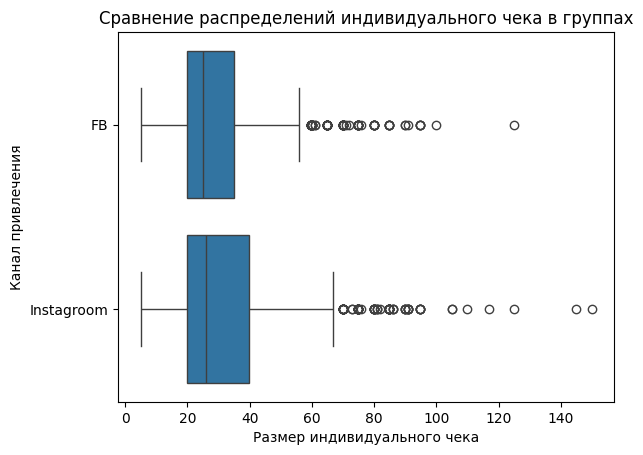

In [11]:
sns.boxplot(data = report, x = 'revenue', y = 'ad_network')
plt.xlabel('Размер индивидуального чека'), plt.ylabel('Канал привлечения'), plt.title(
'Сравнение распределений индивидуального чека в группах');

Я утверждаю, что процент конверсии новых пользователей в покупателей составляет 3%. Давайте проверим это утверждение с помощью z-теста для пропорций:

In [12]:
# задаем порог
value = 0.03
# готовим данные
buyers = purchases['user_id'].nunique()
total_users = new_users['user_id'].nunique()
print('Покупатели: {}, общее число пользователей: {}, конверсия: {}'.format(buyers, total_users, buyers / total_users))

Покупатели: 3399, общее число пользователей: 166447, конверсия: 0.02042091476566114


In [15]:
%%capture
!pip install statsmodels

In [16]:
from statsmodels.stats.proportion import proportions_ztest
# задаем уровень значимости
alpha = 0.05
#проводим тест
p_value = proportions_ztest(buyers, total_users, value = value)[1]
print('p-value: {:.5f}'.format(p_value))
# анализируем результат
if p_value < alpha:
    print('Отвергаем нулевую гипотезу: доля целевых наблюдений не равна заданному порогу.')
else:
    print('Не отвергаем нулевую гипотезу: доля целевых наблюдений равна заданному порогу.')

p-value: 0.00000
Отвергаем нулевую гипотезу: доля целевых наблюдений не равна заданному порогу.


z-тест для пропорций очень часть используется для анализа разного рода маркетинговых задач,
поэтому в интертене есть масса готовых калькуляторов для расчета результатов z-теста. Например, [вот этот](https://epitools.ausvet.com.au/ztestone)

С помощью z-теста для пропорций проверим, отличается ли процент конверсии новых пользователей
в покупателей для рекламных источников FB и Instagroom.

In [18]:
# готовим данные
buyers_fb = purchases.query('ad_network == "FB"')['user_id'].nunique()
total_users_fb = new_users.query('ad_network == "FB"')['user_id'].nunique()
buyers_ig = purchases.query('ad_network == "Instagroom"')['user_id'].nunique()
total_users_ig = new_users.query('ad_network == "Instagroom"')['user_id'].nunique()
print('FB Покупатели: {}, общее число пользователей: {}, коневерсия: {}'.format(buyers_fb, total_users_fb, buyers_fb / total_users_fb))
print('Instagroom Покупатели: {}, общее число пользователей: {}, коневерсия: {}'.format(buyers_ig, total_users_ig, buyers_ig / total_users_ig))

FB Покупатели: 2281, общее число пользователей: 114297, коневерсия: 0.01995677926804728
Instagroom Покупатели: 1118, общее число пользователей: 52150, коневерсия: 0.021438159156279963


In [19]:
from statsmodels.stats.proportion import proportions_ztest
# задаем уровень значимости
alpha = 0.05
#проводим тест
p_value = proportions_ztest([buyers_fb, buyers_ig], [total_users_fb, total_users_ig])[1]
print('p-value: {:.5f}'.format(p_value))
# анализируем результат
if p_value < alpha:
    print('Отвергаем нулевую гипотезу: доли целевых наблюдений в двух группах отличаются.')
else:
    print('Не отвергаем нулевую гипотезу: доли целевых наблюдений в обеих группах одинаковые.')

p-value: 0.04747
Отвергаем нулевую гипотезу: доли целевых наблюдений в двух группах отличаются.


Так же, как и в случае с одновыборочным тестом, в сети существуют и калькуляторы для
двухвыборочного z-теста для пропорций. Например, [этот](https://epitools.ausvet.com.au/ztesttwo)

In [20]:
import numpy as np
import statsmodels.api as sm

# данные выборки (рост студентов в см)
student_heights = np.array([172, 168, 175, 169, 171, 174, 170, 173, 167, 176, 
                             169, 172, 171, 174, 168, 177, 170, 175, 169, 171])

# параметры генеральной совокупности
population_mean = 170  # средний рост населения
population_std = 8     # стандартное отклонение роста населения

# Выполняем z-тест
z_score, p_value = sm.stats.ztest(student_heights, value=population_mean, alternative='two-sided')

print(f"Z-статистика: {z_score:.2f}")
print(f"P-значение: {p_value:.4f}")

# интерпретация результатов
alpha = 0.05
if p_value < alpha:
    print("Отвергаем нулевую гипотезу, существует значимая разница в росте.")
else:
    print("Не отвергаем нулевую гипотезу, значимой разницы в росте нет.")


Z-статистика: 2.40
P-значение: 0.0165
Отвергаем нулевую гипотезу, существует значимая разница в росте.


Одновыборочный z-тест в общем случае

In [21]:
import statsmodels.api as sm

# данные выборки (рост студентов в см)
student_heights = np.array([172, 168, 175, 169, 171, 174, 170, 173, 167, 176, 
                             169, 172, 171, 174, 168, 177, 170, 175, 169, 171])

# параметры генеральной совокупности
population_mean = 170  # средний рост населения
population_std = 8     # стандартное отклонение роста населения

# Выполняем z-тест
_, p_value = sm.stats.ztest(student_heights, value=population_mean, alternative='two-sided')

print(f"p-value: {p_value:.4f}")

# интерпретация результатов
alpha = 0.05
if p_value < alpha:
    print("Отвергаем нулевую гипотезу, существует значимая разница в росте.")
else:
    print("Не отвергаем нулевую гипотезу, значимой разницы в росте нет.")


p-value: 0.0165
Отвергаем нулевую гипотезу, существует значимая разница в росте.


Тест Манна-Уитни проводится с помощью функции stats.mannwhitneyu. Вот ее входные параметры
stats.mannwhitneyu(a, b, alternative = 'two-sided'):
a - данные из первой выборки;
b - данные из второй выборки;
alternative = 'two-sided' - очень важный параметр, показывающий функции, проводить ли
односторонний или двусторонний тест

In [22]:
import scipy.stats as stats
# готовим данные
report_fb = report.query('ad_network == "FB"')['revenue']
report_ig = report.query('ad_network == "Instagroom"')['revenue']
# задаем уровень значимости
alpha = 0.05
#проводим тест
p_value = stats.mannwhitneyu(report_fb, report_ig, alternative = 'two-sided').pvalue
print('p-value: {:.5f}'.format(p_value))
# анализируем результат
if p_value < alpha:
    print('Отвергаем нулевую гипотезу: данные двух выборок получены из разных генеральных совокупностей.')
else:
    print('Не отвергаем нулевую гипотезу: данные двух выборок получены из одной генеральной совокупности.')

p-value: 0.01792
Отвергаем нулевую гипотезу: данные двух выборок получены из разных генеральных совокупностей.
